Проект сегментация покупателей по признакам. ниже импортируем библиотечки/ В данной работе со всего сета данных будем брать только 1000 так как так будет быстрее грузить ноут и вообще все будет работать лучше так что да вот так вот. 

In [2]:
import pandas as pd
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
#далее загружаем данные
all_data_path='C:/Users/sea/Desktop/---/customersegmentation/data/data.csv'
all_data=pd.read_csv(all_data_path, encoding='latin1')
df=all_data[:1000]#берем поменьше данных чтобы лучше грузилос 

далее проведем первичный анализ данных

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    1000 non-null   object 
 1   StockCode    1000 non-null   object 
 2   Description  999 non-null    object 
 3   Quantity     1000 non-null   int64  
 4   InvoiceDate  1000 non-null   object 
 5   UnitPrice    1000 non-null   float64
 6   CustomerID   999 non-null    float64
 7   Country      1000 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 62.6+ KB


,Quantity,UnitPrice,CustomerID
count,1000.000000,1000.000000,999.000000
mean,12.785000,3.037110,16023.130130
std,38.423706,5.896942,1865.129933
min,-24.000000,0.000000,12431.000000
25%,2.000000,1.250000,14688.000000
50%,4.000000,2.100000,16210.000000
75%,12.000000,3.750000,17908.000000
max,600.000000,165.000000,18085.000000


после проведенного анализа видно,что в данных 1000 строк и 8 колонок. данные содержат информацию о транзакциях магазина: номерсчета, код товара, описание, количество, дата, цена, ID клиента и страна. В данных есть отрицательные значения в Quantity - это возвраты в магазин (от них надо очистить чтобы праивльно произвести сегментацию) 

In [5]:
df=df.drop_duplicates()
df=df.dropna()
df=df[df['Quantity']>=0]
df=df[df['UnitPrice']>0]
df=df[df['CustomerID'].notna()]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 966 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    966 non-null    object 
 1   StockCode    966 non-null    object 
 2   Description  966 non-null    object 
 3   Quantity     966 non-null    int64  
 4   InvoiceDate  966 non-null    object 
 5   UnitPrice    966 non-null    float64
 6   CustomerID   966 non-null    float64
 7   Country      966 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 67.9+ KB


после очистки данных от возвратов, пустых значений, повторяющихся данных, а также удалила данные с пустым ID в итоге осталось 966 строк с которыми мы будем работать.

In [6]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 966 entries, 0 to 999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    966 non-null    object        
 1   StockCode    966 non-null    object        
 2   Description  966 non-null    object        
 3   Quantity     966 non-null    int64         
 4   InvoiceDate  966 non-null    datetime64[ns]
 5   UnitPrice    966 non-null    float64       
 6   CustomerID   966 non-null    float64       
 7   Country      966 non-null    object        
 8   TotalPrice   966 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 75.5+ KB


выше мы создали колонку TotalPrice, которая равна произведению Quantity*UnitPrice. С помозью данной колонки мы можем увидеть сколько потратил каждый клиент. Также мы преобразовали дату, с помощью этого мы теперь можем найти дату последней покупки каждого клиента, посчитать разницу между датами покупок, а также узнать сколько дней прошло с послежней покупки.

RFM-анализ:

In [12]:
data_rfm=max(df['InvoiceDate'])
rfm=df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (data_rfm-x.max()).days,
    'InvoiceNo': 'nunique', #считаем кол-во уникальных чеков
    'TotalPrice': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recenty',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
})
print(rfm.head())
print(rfm.info())
print(rfm.describe())

            Recenty  Frequency  Monetary
CustomerID                              
12431.0           0          1    358.25
12583.0           0          1    855.86
12791.0           0          1    192.60
12838.0           0          1    390.79
13047.0           0          3    366.63
<class 'pandas.core.frame.DataFrame'>
Index: 46 entries, 12431.0 to 18085.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recenty    46 non-null     int64  
 1   Frequency  46 non-null     int64  
 2   Monetary   46 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 1.4 KB
None
       Recenty  Frequency     Monetary
count     46.0  46.000000    46.000000
mean       0.0   1.326087   534.966957
std        0.0   1.383303   657.172955
min        0.0   1.000000    34.800000
25%        0.0   1.000000   232.385000
50%        0.0   1.000000   355.035000
75%        0.0   1.000000   452.590000
max        0.0  10.000000  3702.120000

после проведеня RFM-анализа у нас 3 колонки: Recenty - количество дней с полседней покупки (в данном фрагменте данных у всех 0, поскольку мы брали из начала датасета), Frequency - количество покупок/уникальных, Monetary - общая сумма потраченнных денег. в хоче проведения анализа из 966 очищенных транзакций у нас осталось всего 46строк - это значит, что всего 46 человек совершили 966 транзакций. Из статистики представленной с помощью функции describe() можно заметить, что минимальное количество покупок в данном датасете - 1, максимальное количество покупок - 84, минимальная сумма затрат - 34.8, максимальная сумма затрат - 3702.12

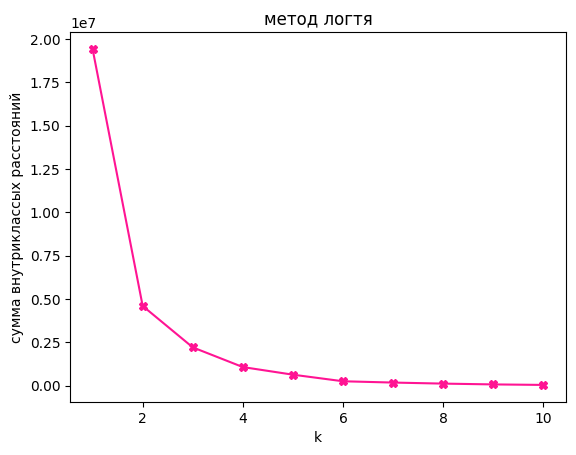

In [13]:
#масштабирование
scaler=StandardScaler()
df_scaled=scaler.fit_transform(rfm)
#используем метод логтя
z=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm)
    z.append(kmeans.inertia_)
plt.plot(range(1,11), z, marker='X', color='deeppink')
plt.title("метод логтя")
plt.ylabel("сумма внутриклассых расстояний")
plt.xlabel("k")
plt.show()

мы произвели масштабирование поскольку в наших данных есть признаки с обльшим разбросом и они будут доминировать, далее с помощью метода логтя нашли к=3. на графике можно визуально увидеть точку к - это место где кривая перестает резко падать.

In [14]:
#кластеризация с помозью kmeans
kmeans=KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(df_scaled)
#добавление меток кластеров к исх дан
rfm['Cluster'] = clusters
print(rfm)
print(rfm['Cluster'].value_counts(normalize=True) * 100)#в процентах кол-во людей

            Recenty  Frequency  Monetary  Cluster
CustomerID                                       
12431.0           0          1    358.25        0
12583.0           0          1    855.86        0
12791.0           0          1    192.60        0
12838.0           0          1    390.79        0
13047.0           0          3    366.63        0
13255.0           0          1    225.70        0
13408.0           0          1   1024.68        0
13448.0           0          2    443.96        0
13694.0           0          1    842.12        0
13705.0           0          1    318.14        0
13747.0           0          1     79.60        0
13748.0           0          1    204.00        0
13758.0           0          1    362.45        0
13767.0           0          1    507.88        0
14045.0           0          1    326.40        0
14307.0           0          1    783.11        0
14688.0           0          1    444.98        0
14729.0           0          1    268.37        0


In [17]:
cluster_stats = rfm.groupby('Cluster')[['Recenty', 'Frequency', 'Monetary']].mean()
print("среднее значение по группам:")
print(cluster_stats.round(2))
print(rfm['Cluster'].value_counts())#кол-во людей в каждой группе

среднее значение по группам:
         Recenty  Frequency  Monetary
Cluster                              
0            0.0       1.12    359.68
1            0.0      10.00   1499.34
2            0.0       1.33   2667.53
Cluster
0    42
2     3
1     1
Name: count, dtype: int64


глядя на среднее значение значения по группам, можно сделать вывод, что группа под номером 0 - это средник покупатели (покупают 1,12 раза за период и тратят не большие суммы 359 - это основная масса данных покупателей) - можно внедрить программы лояльности, чтобы заинтересовать клиента, также попробовать добавить скидки за регулярность. это будет мотивировать его вернуться через время. группа 1 - это активные покупатели (покупают часто и много в текущих данных у нас 1 такой человек), предлагать эксклюзивные продложения, использовать стандартные email-рассылки, использовать накопительные/бонусные системы. группа 2 - это VIP клиенты (покупают редко, но покупают дорогие товары) - предоставить ранний доступ к новинкам, сделать бесплатную достаку, прикрепить за покупателем персонального менеджера.